In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 5000

project_type = np.random.choice(
    ["Substation","Transmission Line","Underground Cable"],
    n
)

terrain = np.random.choice(
    ["Plain","Hilly","Urban","Forest"],
    n
)

material_cost = np.random.randint(500000,5000000,n)

labour_cost = np.random.randint(200000,2000000,n)

reg_delay = np.random.randint(0,120,n)

weather = np.random.randint(1,10,n)

vendor = np.random.randint(1,10,n)

demand = np.random.randint(1,10,n)

manpower = np.random.randint(1,10,n)

planned_cost = material_cost + labour_cost

actual_cost = (
    planned_cost
    + reg_delay*10000
    + (10-vendor)*50000
    + np.random.randint(-100000,300000,n)
)

planned_days = np.random.randint(90,500,n)

actual_days = (
    planned_days
    + reg_delay
    + (10-manpower)*5
    + np.random.randint(-20,50,n)
)

df = pd.DataFrame({
    "Project_Type":project_type,
    "Terrain":terrain,
    "Material_Cost":material_cost,
    "Labour_Cost":labour_cost,
    "Regulatory_Delay":reg_delay,
    "Weather_Score":weather,
    "Vendor_Score":vendor,
    "Demand_Supply_Index":demand,
    "Manpower_Availability":manpower,
    "Planned_Cost":planned_cost,
    "Actual_Cost":actual_cost,
    "Planned_Days":planned_days,
    "Actual_Days":actual_days
})

df.to_csv("powergrid_dataset.csv",index=False)

print(df.head())

        Project_Type Terrain  Material_Cost  Labour_Cost  Regulatory_Delay  \
0  Underground Cable   Urban        1385621      1589900               103   
1         Substation   Plain        4993122      1581173                47   
2  Underground Cable   Urban        1061548      1071836                44   
3  Underground Cable  Forest        1204824      1130728               118   
4         Substation  Forest        2332500      1251628                92   

   Weather_Score  Vendor_Score  Demand_Supply_Index  Manpower_Availability  \
0              9             1                    6                      6   
1              1             6                    5                      6   
2              6             6                    5                      8   
3              7             1                    9                      2   
4              2             8                    3                      8   

   Planned_Cost  Actual_Cost  Planned_Days  Actual_Days  
0   

In [2]:
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

df = pd.read_csv("powergrid_dataset.csv")

features = [
"Project_Type",
"Terrain",
"Material_Cost",
"Labour_Cost",
"Regulatory_Delay",
"Weather_Score",
"Vendor_Score",
"Demand_Supply_Index",
"Manpower_Availability",
"Planned_Cost",
"Planned_Days"
]

X = df[features]

y_cost = df["Actual_Cost"]
y_days = df["Actual_Days"]

categorical = [
"Project_Type",
"Terrain"
]

numeric = [
"Material_Cost",
"Labour_Cost",
"Regulatory_Delay",
"Weather_Score",
"Vendor_Score",
"Demand_Supply_Index",
"Manpower_Availability",
"Planned_Cost",
"Planned_Days"
]

preprocessor = ColumnTransformer([
(
"cat",
OneHotEncoder(handle_unknown="ignore"),
categorical
),
(
"num",
"passthrough",
numeric
)
])

cost_model = Pipeline([
("prep",preprocessor),
("model",RandomForestRegressor(
n_estimators=200,
random_state=42
))
])

days_model = Pipeline([
("prep",preprocessor),
("model",RandomForestRegressor(
n_estimators=200,
random_state=42
))
])

cost_model.fit(X,y_cost)
days_model.fit(X,y_days)

joblib.dump(cost_model,"cost_model.pkl")
joblib.dump(days_model,"days_model.pkl")

print("Models Saved")

Models Saved


In [3]:
input_data = pd.DataFrame({
    "Project_Type":["Substation"],
    "Terrain":["Plain"],
    "Material_Cost":[2000000],
    "Labour_Cost":[800000],
    "Regulatory_Delay":[30],
    "Weather_Score":[7],
    "Vendor_Score":[6],
    "Demand_Supply_Index":[5],
    "Manpower_Availability":[7],
    "Planned_Cost":[2800000],
    "Planned_Days":[180]
})

predicted_cost = cost_model.predict(input_data)[0]

predicted_days = days_model.predict(input_data)[0]

planned_cost = input_data["Planned_Cost"].iloc[0]

cost_overrun = predicted_cost - planned_cost

print("Predicted Cost:", predicted_cost)
print("Cost Overrun:", cost_overrun)

Predicted Cost: 3528564.535
Cost Overrun: 728564.5350000001


In [4]:
if cost_overrun < 100000:
    risk = "Low"
elif cost_overrun < 500000:
    risk = "Medium"
else:
    risk = "High"

print("Risk Level:", risk)

Risk Level: High


In [5]:
vendor_score = input_data["Vendor_Score"].iloc[0]
manpower = input_data["Manpower_Availability"].iloc[0]
regulatory_delay = input_data["Regulatory_Delay"].iloc[0]
weather_score = input_data["Weather_Score"].iloc[0]

issues = []

if vendor_score < 5:
    issues.append("Poor Vendor Performance")

if manpower < 5:
    issues.append("Manpower Shortage")

if regulatory_delay > 60:
    issues.append("Regulatory Approval Delays")

if weather_score < 4:
    issues.append("Weather Risk")

if len(issues) == 0:
    issues.append("No Major Risks Detected")

print("Hotspots:")
for issue in issues:
    print("-", issue)

Hotspots:
- No Major Risks Detected


In [6]:
health_score = 100

if vendor_score < 5:
    health_score -= 20

if manpower < 5:
    health_score -= 20

if regulatory_delay > 60:
    health_score -= 30

if weather_score < 4:
    health_score -= 15

health_score = max(0, health_score)

print("Project Health Score:", health_score)

Project Health Score: 100


In [7]:
print("\n===== PROJECT REPORT =====")

print("Predicted Cost:", round(predicted_cost))
print("Predicted Completion Days:", round(predicted_days))

print("Risk Level:", risk)

print("Health Score:", health_score)

print("\nHotspots:")

for issue in issues:
    print("-", issue)


===== PROJECT REPORT =====
Predicted Cost: 3528565
Predicted Completion Days: 242
Risk Level: High
Health Score: 100

Hotspots:
- No Major Risks Detected


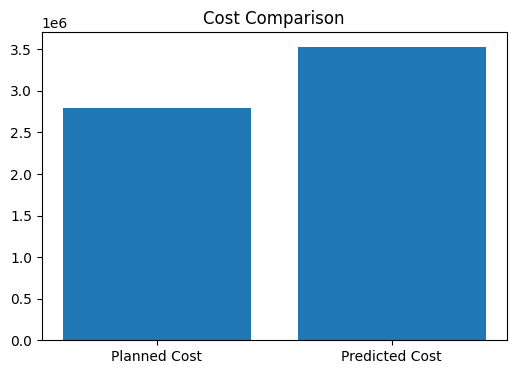

In [8]:
import matplotlib.pyplot as plt

labels = ["Planned Cost", "Predicted Cost"]
values = [planned_cost, predicted_cost]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Cost Comparison")
plt.show()

In [9]:
pip install streamlit joblib pandas scikit-learn matplotlib

In [10]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd

cost_model = joblib.load("cost_model.pkl")
days_model = joblib.load("days_model.pkl")

st.title("POWERGRID Project Cost & Timeline Prediction")

ptype = st.selectbox(
    "Project Type",
    ["Substation","Transmission Line","Underground Cable"]
)

terrain = st.selectbox(
    "Terrain",
    ["Plain","Hilly","Urban","Forest"]
)

material_cost = st.number_input("Material Cost", value=1000000)
labour_cost = st.number_input("Labour Cost", value=500000)
reg_delay = st.slider("Regulatory Delay",0,120,20)
weather = st.slider("Weather Score",1,10,7)
vendor = st.slider("Vendor Score",1,10,7)
demand = st.slider("Demand Supply Index",1,10,5)
manpower = st.slider("Manpower Availability",1,10,7)
planned_days = st.number_input("Planned Days", value=180)

planned_cost = material_cost + labour_cost

if st.button("Predict"):

    input_data = pd.DataFrame({
        "Project_Type":[ptype],
        "Terrain":[terrain],
        "Material_Cost":[material_cost],
        "Labour_Cost":[labour_cost],
        "Regulatory_Delay":[reg_delay],
        "Weather_Score":[weather],
        "Vendor_Score":[vendor],
        "Demand_Supply_Index":[demand],
        "Manpower_Availability":[manpower],
        "Planned_Cost":[planned_cost],
        "Planned_Days":[planned_days]
    })

    predicted_cost = cost_model.predict(input_data)[0]
    predicted_days = days_model.predict(input_data)[0]

    st.success("Prediction Completed")

    st.write("Predicted Cost:", round(predicted_cost))
    st.write("Predicted Completion Days:", round(predicted_days))

Overwriting app.py


In [11]:
!ls


app.py	cost_model.pkl	days_model.pkl	powergrid_dataset.csv  sample_data


In [27]:
!streamlit run app.py



2026-06-24 06:10:45.226 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.73.161.122:8501

  Stopping...


In [24]:
!pip install pyngrok

In [25]:
from pyngrok import ngrok

ngrok.set_auth_token("30Sn9CAwj3FBaQSUpnuzGBl2hwq_6jzqpgaa5wmrKi2m2GnT5")

In [26]:
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://a2de-34-73-161-122.ngrok-free.app" -> "http://localhost:8501"
